In [3]:
import tensorflow as tf

from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt

In [4]:
#get the dataset in
from tensorflow.keras.datasets import cifar10

In [5]:
# load datset 
(x_train,y_train), (x_test,y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 102s 1us/step


In [8]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 1)
(10000, 1)


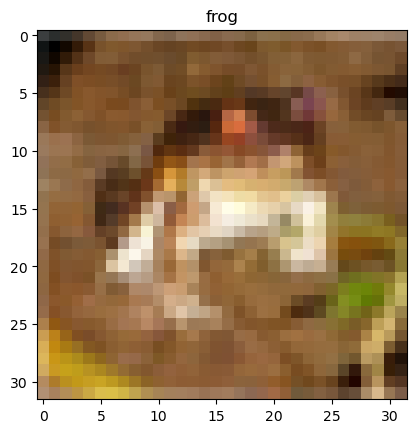

In [9]:
class_name = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

plt.imshow(x_train[0])
plt.title(class_name[y_train[0][0]])
plt.show()

In [10]:
#Normalize the images 
x_train = x_train/255.0
x_test = x_test/255.0

In [12]:
# Building a Simple CNN

model = models.Sequential()

#convolutional layer
model.add(
    layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape = (32,32,3)
        
    )
)

/home/anshuman/D_Drive/Coding/DataScience/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779191270.555713  395000 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779191270.556677  395000 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [14]:
#pooling
model.add(layers.MaxPooling2D(2,2))

In [15]:
#another convolutional layer 
model.add(layers.Conv2D(64,(3,3),activation="relu"))
model.add(layers.MaxPooling2D(2,2))


In [16]:
#Flatten
model.add(layers.Flatten())

In [17]:
#Dense Layer
model.add(layers.Dense(64,activation="relu"))

In [18]:
#Output layer for 10 output classification 
model.add(layers.Dense(10,activation="softmax"))

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

history = model.fit(
    x_train,
    y_train,
    epochs = 10,
    validation_data = (x_test,y_test)
)

Epoch 1/10


2026-05-19 17:26:28.553483: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3840 - loss: 1.7039

2026-05-19 17:27:03.212917: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 122880000 exceeds 10% of free system memory.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 22ms/step - accuracy: 0.3843 - loss: 1.7033 - val_accuracy: 0.5708 - val_loss: 1.2052
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.5922 - loss: 1.1516 - val_accuracy: 0.6332 - val_loss: 1.0509
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.6516 - loss: 1.0005 - val_accuracy: 0.6524 - val_loss: 0.9942
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.6870 - loss: 0.8998 - val_accuracy: 0.6578 - val_loss: 0.9907
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.7106 - loss: 0.8321 - val_accuracy: 0.6636 - val_loss: 0.9728
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7289 - loss: 0.7779 - val_accuracy: 0.6898 - val_loss: 0.9102
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.7482 - loss: 0.7249 - val_accuracy: 0.6879 - val_loss: 0.9177
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.7594 - loss: 0.68

In [22]:
test_loss ,test_accuracy = model.evaluate(x_test,y_test)
print("Test_accuracy : " , test_accuracy)

 16/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6672 - loss: 1.0273

2026-05-19 17:32:53.260787: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 122880000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6933 - loss: 0.9335
Test_accuracy :  0.6934999823570251


In [23]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

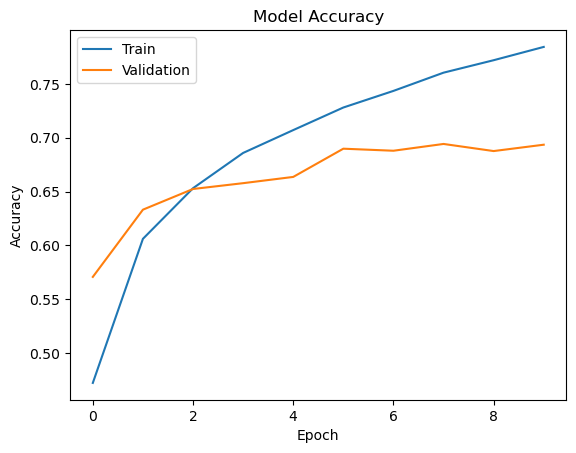

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()